In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini")

In [2]:
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

In [3]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    # Get summary if it exists
    summary = state.get("summary", "")
    
    # If there is summary, then we add it
    if summary:
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"
        
        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

In [4]:
def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get("summary", "")
    
    # Create our summarization prompt
    if summary:
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    
    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

In [5]:
from langgraph.graph import END

# Determine whether to end or summarize the conversation
def should_continue(state: State):
    """Return the next node to execute."""
    messages = state['messages']
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) >= 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return "end"

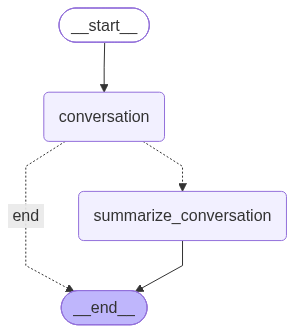

In [6]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

# Define a new graph
workflow = StateGraph(State)

# Add nodes
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")

# Add conditional edge from conversation node
workflow.add_conditional_edges("conversation", should_continue, {
    "summarize_conversation": "summarize_conversation",
    "end": END
})

# After summarization, end the graph
workflow.add_edge("summarize_conversation", END)

# Compile with checkpointer for memory
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# Create a thread (conversation session)
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Siva")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i Love python !")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Siva! How can I assist you today?
================================== Ai Message ==================================

Your name is Siva! How can I help you today?
================================== Ai Message ==================================

That's great to hear! Python is a versatile and powerful programming language. What do you love most about it? Are you working on any specific projects or learning anything new?


In [8]:
graph.get_state(config).values.get("summary", "")

'Sure! In the conversation, Siva introduced himself and expressed his love for Python. I responded by asking what he enjoys most about the language and if he is working on any specific projects or learning new aspects of Python.'

In [9]:
input_message = HumanMessage(content="tell me about elon musk")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Elon Musk is a billionaire entrepreneur and business magnate known for his role in several high-profile technology companies. Here are some key points about him:

1. **Early Life**: Born on June 28, 1971, in Pretoria, South Africa, Musk showed an early interest in computers and technology. He moved to the United States to attend Stanford University but dropped out after two days to pursue entrepreneurial ventures.

2. **Zip2 Corporation**: Musk co-founded his first company, Zip2, in 1996, which provided online business directories and maps. Compaq acquired Zip2 in 1999 for about $307 million.

3. **PayPal**: He then co-founded X.com, an online payment company, which later became PayPal. PayPal was sold to eBay in 2002 for $1.5 billion in stock.

4. **SpaceX**: In 2002, Musk founded SpaceX (Space Exploration Technologies Corp.) with the goal of reducing space transportation costs and enabling the colonizat

In [10]:
graph.get_state(config).values.get("summary", "")

'Sure! In the conversation, Siva introduced himself and expressed his love for Python. I responded by asking what he enjoys most about the language and if he is working on any specific projects or learning new aspects of Python.'